# 06 — Correlation Heatmap
Which socioeconomic factors correlate with vaccination coverage?

In [1]:
import pickle
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

OUT = os.path.join("..", "outputs")
os.makedirs(OUT, exist_ok=True)

In [2]:
with open(os.path.join("..", "data", "processed.pkl"), "rb") as f:
    df = pickle.load(f)

df["date"] = pd.to_datetime(df["date"])
print(f"Vaccination data: {df.shape}")

Vaccination data: (62980, 21)


In [3]:
# pull socioeconomic metadata from the main OWID dataset
owid_url = "https://raw.githubusercontent.com/owid/covid-19-data/master/public/data/owid-covid-data.csv"
meta_cols = ["location", "gdp_per_capita", "population", "population_density",
             "median_age", "aged_65_older", "human_development_index", "life_expectancy"]
print("Fetching OWID metadata...")
owid = pd.read_csv(owid_url, usecols=meta_cols)
meta = owid.groupby("location").first().reset_index()
print(f"Metadata for {len(meta)} locations")

Fetching OWID metadata...


Metadata for 255 locations


## 1. Build country-level snapshot

In [4]:
latest = df.sort_values("date").groupby("location").last().reset_index()
latest = latest.merge(meta, on="location", how="left")

corr_cols = [
    "people_fully_vaccinated_per_hundred", "total_boosters_per_hundred",
    "gdp_per_capita", "population", "population_density",
    "median_age", "aged_65_older", "human_development_index", "life_expectancy"
]
corr_df = latest[corr_cols].dropna()
print(f"Countries with all columns: {len(corr_df)}")

Countries with all columns: 162


## 2. Pearson correlation heatmap

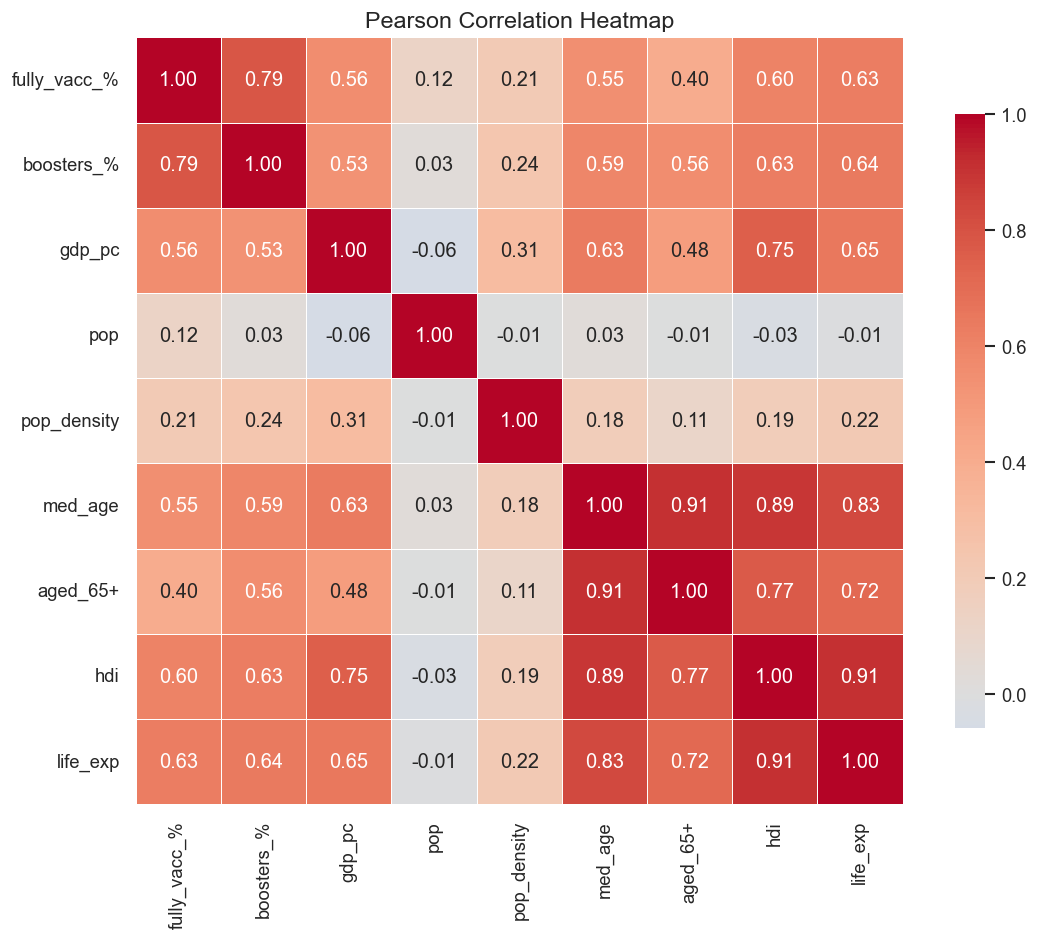

In [5]:
corr_matrix = corr_df.corr(method="pearson")

# shorter labels for readability
short = {
    "people_fully_vaccinated_per_hundred": "fully_vacc_%",
    "total_boosters_per_hundred": "boosters_%",
    "gdp_per_capita": "gdp_pc",
    "population": "pop",
    "population_density": "pop_density",
    "median_age": "med_age",
    "aged_65_older": "aged_65+",
    "human_development_index": "hdi",
    "life_expectancy": "life_exp"
}
corr_display = corr_matrix.rename(index=short, columns=short)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_display, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={"shrink": 0.8})
ax.set_title("Pearson Correlation Heatmap", fontsize=14)
fig.tight_layout()
fig.savefig(os.path.join(OUT, "correlation_heatmap.png"))
plt.show()

## 3. Top 5 strongest positive correlations

In [6]:
# unstack and remove self-correlations and duplicates
pairs = (
    corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)
pairs.columns = ["var_1", "var_2", "corr"]

top_pos = pairs.nlargest(5, "corr")
print("Top 5 positive correlations:")
for _, r in top_pos.iterrows():
    print(f"  {r['var_1']:45s} ↔ {r['var_2']:45s}  r = {r['corr']:+.3f}")

Top 5 positive correlations:
  median_age                                    ↔ aged_65_older                                  r = +0.910
  human_development_index                       ↔ life_expectancy                                r = +0.905
  median_age                                    ↔ human_development_index                        r = +0.893
  median_age                                    ↔ life_expectancy                                r = +0.832
  people_fully_vaccinated_per_hundred           ↔ total_boosters_per_hundred                     r = +0.785


## 4. Top 5 strongest negative correlations

In [7]:
top_neg = pairs.nsmallest(5, "corr")
print("Top 5 negative correlations:")
for _, r in top_neg.iterrows():
    print(f"  {r['var_1']:45s} ↔ {r['var_2']:45s}  r = {r['corr']:+.3f}")

Top 5 negative correlations:
  gdp_per_capita                                ↔ population                                     r = -0.058
  population                                    ↔ human_development_index                        r = -0.035
  population                                    ↔ life_expectancy                                r = -0.009
  population                                    ↔ population_density                             r = -0.007
  population                                    ↔ aged_65_older                                  r = -0.007


## 5. Pairplot — key variables

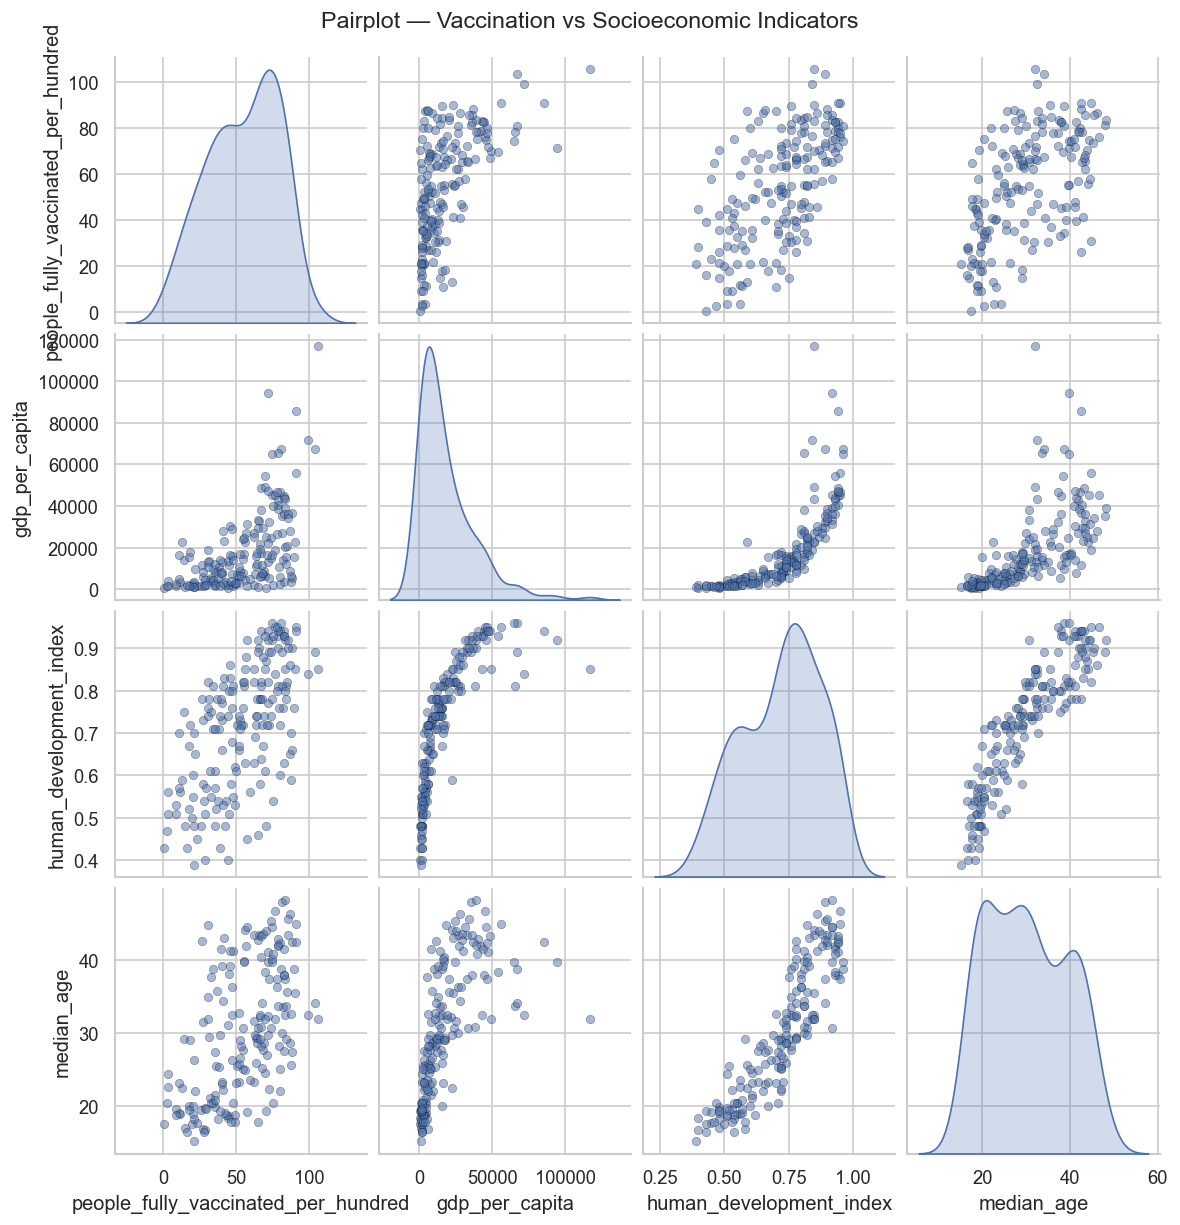

In [8]:
pair_cols = ["people_fully_vaccinated_per_hundred",
             "gdp_per_capita", "human_development_index", "median_age"]
pair_df = latest[pair_cols].dropna()

g = sns.pairplot(pair_df, diag_kind="kde",
                 plot_kws={"alpha": 0.5, "s": 25, "edgecolor": "black", "linewidth": 0.3},
                 diag_kws={"fill": True})
g.figure.suptitle("Pairplot — Vaccination vs Socioeconomic Indicators", y=1.02, fontsize=14)
g.figure.savefig(os.path.join(OUT, "pairplot_key_vars.png"), bbox_inches="tight")
plt.show()